Bibliotecas utilziadas en EDA

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings("ignore")
import os
os.makedirs('../reports', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

Formato visual utilizado

In [2]:
#Formato visual
sns.set_style("whitegrid")
plt.rcParams ["figure.figsize"] = (12,6)

Carga de datos y visualización de analisis descriptivo

In [7]:
#Carga de datos
df = pd.read_csv("/content/telco_churn.csv.csv")

#Información del data set
print ("SHAPE", df.shape)
print ("\nColumnas y tipo:")
print (df.dtypes)
print ("\nPrimeras Filas")
print (df.head())
print ("\nInformación general:")
print (df.info())
print ("\nEstadistica Descriptiva:")
print (df.describe())
print ("\nValores nulos:")
print (df.isnull().sum())


SHAPE (7043, 21)

Columnas y tipo:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Primeras Filas
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male      

En  el paso anterior verificamos que Python esta leyendo la columna "TotalCharges" como un valor object, cuando en realidad esa columna deberia visualizarse como float , debiodo a que "TotalCharges" es una unidad de dinero.

In [14]:
#Correción de valores problemáticos en TotalCharges
print ("Valores problematicos:")
print (df[df['TotalCharges'].str.strip()== '']['TotalCharges'].count())

#Visualizamos esos registros
visualizacion = df['TotalCharges'].str.strip() == ''
print("Filas con TotalCharges vacío:", visualizacion.sum())
print (df[visualizacion][['customerID' , 'tenure' , 'MonthlyCharges', 'TotalCharges', 'Churn' ]])

Valores problematicos:
11
Filas con TotalCharges vacío: 11
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No


En este paso de nuestro algoritmo pasamos a limpiar la columna tenure para que nuestra predicción sea mucho más certera.

In [23]:
# DECISIÓN DE LIMPIEZA #1
# Eliminar clientes con tenure = 0 (nunca activaron el servicio, por ende no aportan valor analítico a la ingeniere de variables)
# Justificación: no aportan información predictiva de churn.

print("Registros anteriores", {df.shape[0]})
df = df[df['tenure'] != 0].copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

print (f"\nRegistro después de la limpieza: {df.shape[0]}")
print (f"\nRegistros eliminados: {7043 - df.shape[0]}")
print (f"\nTipo de TotalCharges ahora: {df['TotalCharges'].dtype}")
print (f"\nNulos en TotalCharges: {df['TotalCharges'].isnull().sum()}")

Registros anteriores {7032}

Registro después de la limpieza: 7032

Registros eliminados: 11

Tipo de TotalCharges ahora: float64

Nulos en TotalCharges: 0


Distribución de Churn:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Porcentajes:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


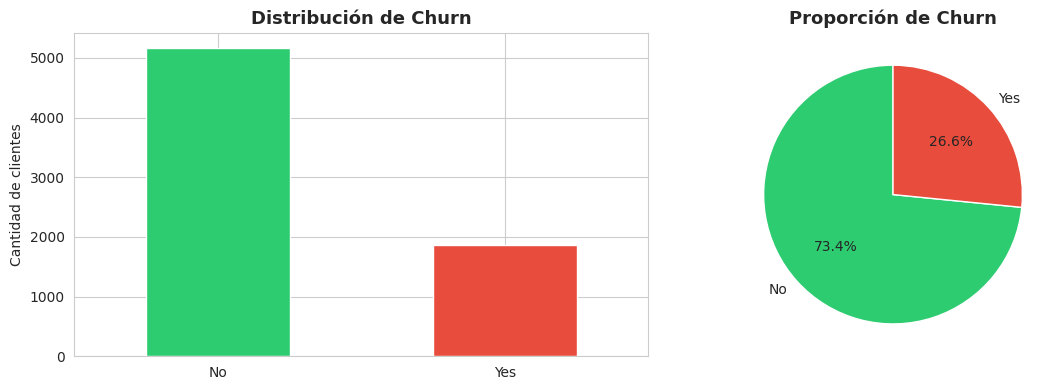

Archivo guardado en reports/


In [47]:
# Análisis monovariado y Distribución variable target (Churn)
print("Distribución de Churn:")
print(df['Churn'].value_counts())
print("\nPorcentajes:")
print(df['Churn'].value_counts(normalize=True).mul(100).round(2))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colores = ['#2ecc71', '#e74c3c']

# Gráfico 1 - Barras
df['Churn'].value_counts().plot(
    kind='bar', ax=axes[0], color=colores, edgecolor='white'
)
axes[0].set_title('Distribución de Churn', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de clientes')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Gráfico 2 - Pie
df['Churn'].value_counts().plot(
    kind='pie', ax=axes[1], colors=colores,
    autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Proporción de Churn', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Archivo guardado en reports/")

In [55]:
contrato_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
print(contrato_churn)
print("\nColumnas:", contrato_churn.columns.tolist())

Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887228  0.112772
Two year        0.971513  0.028487

Columnas: ['No', 'Yes']


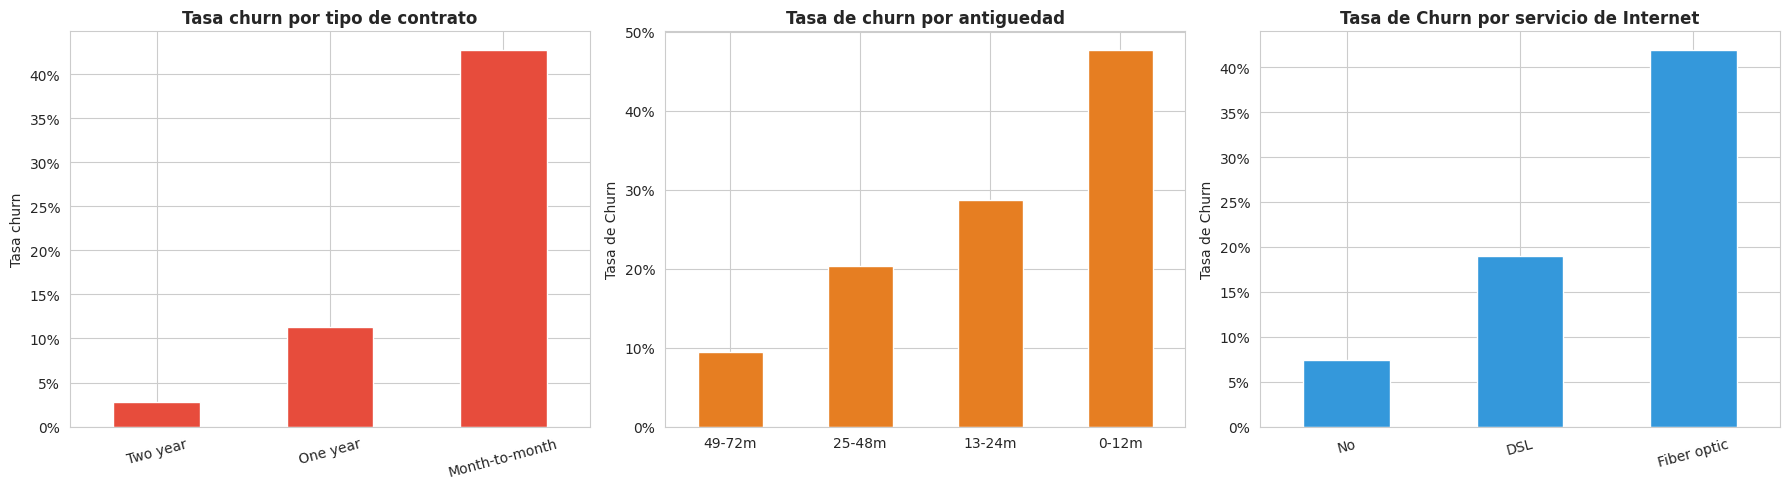

In [60]:
from numpy.random.mtrand import normal
#Análisis bivariado - Variable Churn vs variable clave

fig , axes = plt.subplots(1,3 , figsize =(18,5))

#---Hipotesis 2 : Contratoo vs Churn ----
contrato_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
contrato_churn['Yes'].sort_values().plot(kind='bar', ax=axes[0], color ='#e74c3c', edgecolor ='white')

axes[0].set_title ('Tasa churn por tipo de contrato', fontweight = 'bold')
axes[0].set_ylabel('Tasa churn')
axes[0].set_xlabel('')
axes[0].tick_params(axis ='x', rotation= 15 )
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

#---Hipotesis 3 : Tenure vs Churn ----

df['tenure_group']=pd.cut(df['tenure'], bins=[0,12,24,48,72], labels=['0-12m', '13-24m','25-48m', '49-72m'])
tenure_churn= df.groupby('tenure_group', observed=True)['Churn'].value_counts(normalize=True).unstack()
tenure_churn['Yes'].sort_values().plot(kind='bar', ax= axes[1], color= '#e67e22', edgecolor='white')

axes[1].set_title("Tasa de churn por antiguedad", fontweight='bold')
axes[1].set_ylabel('Tasa de Churn')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.set_major_formatter(lambda y, _: f'{y:.0%}')

# HIPÓTESIS 1: Internet Service vs Churn

internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack()
internet_churn['Yes'].sort_values().plot(kind='bar', ax = axes[2], color='#3498db', edgecolor='white')

axes[2].set_title('Tasa de Churn por servicio de Internet', fontweight='bold')
axes[2].set_ylabel('Tasa de Churn')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation= 15)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.savefig('../reports/02_churn_by_key_variables.png', dpi=150, bbox_inches='tight')
plt.show()


## Conclusiones del Análisis Bivariado

### Hipótesis 1 — Tipo de servicio de internet
CONFIRMADA PARCIALMENTE. Los clientes con Fiber Optic presentan
una tasa de churn del 42%, significativamente mayor que DSL (19%)
y sin internet (7%). Esto sugiere una posible brecha entre el
precio cobrado y el valor percibido en el segmento de fibra óptica.

### Hipótesis 2 — Tipo de contrato  
CONFIRMADA. Los clientes con contrato mes a mes presentan 42%
de churn vs 11% en contrato anual y 3% en contrato bianual.
El tipo de contrato es el predictor más claro de riesgo de churn.

### Hipótesis 3 — Antigüedad del cliente
CONFIRMADA. Los clientes con menos de 12 meses presentan 47%
de churn. A partir de los 24 meses la tasa cae por debajo del 20%.
Los primeros 12 meses son el período crítico de retención.

### Implicación de negocio
El perfil de mayor riesgo es: cliente nuevo (0-12 meses),
con contrato mes a mes y servicio de fibra óptica.
Estos tres factores combinados deben ser la prioridad
del equipo de Customer Success para intervención temprana y detección de los
posibles clientes que pueden llegar a dar la baja del servicio.